# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [2]:
# CIFAR-10 Image Classification - ANN vs CNN
# Assignment: Build image classification model on CIFAR-10 and analyze
# performance across architectures and training strategies
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [7]:
!pip install -q datasets

In [9]:
# we downloaded dataset from hugging face it is much faster than any other option
dataset = load_dataset("uoft-cs/cifar10")

x_train = np.array([np.array(img) for img in dataset['train']['img']])
y_train = np.array(dataset['train']['label']).reshape(-1, 1)

x_test = np.array([np.array(img) for img in dataset['test']['img']])
y_test = np.array(dataset['test']['label']).reshape(-1, 1)

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [11]:
# just checking how balanced the dataset is across classes
# if one class had way more images than others, our model would get biased

unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(class_names, counts)))


{'airplane': np.int64(5000), 'automobile': np.int64(5000), 'bird': np.int64(5000), 'cat': np.int64(5000), 'deer': np.int64(5000), 'dog': np.int64(5000), 'frog': np.int64(5000), 'horse': np.int64(5000), 'ship': np.int64(5000), 'truck': np.int64(5000)}


## 🖼️ Visualize Sample Images

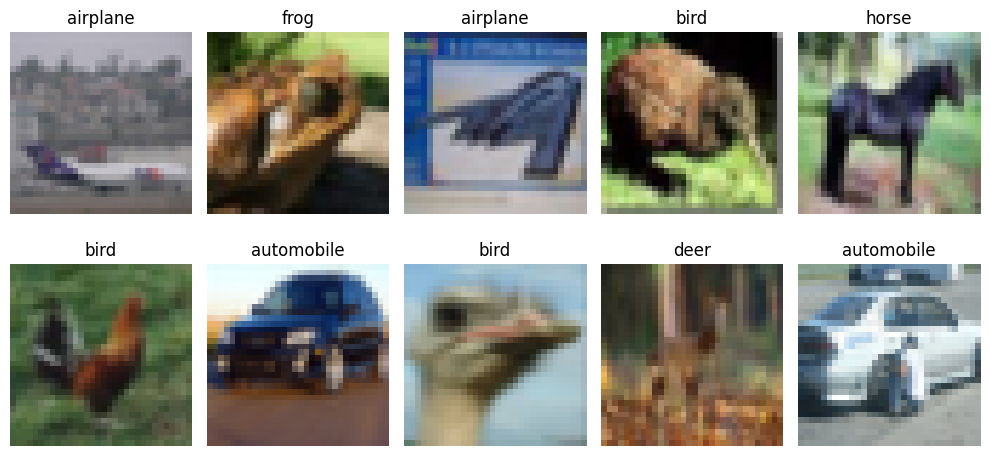

In [12]:
# visualization before touching anything
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()


# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [13]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

In [31]:

print("Flattened shape for ANN:", x_train_flat.shape)
print("Normal shape for CNN:", x_train_norm.shape)

# quick sanity check that normalization worked correctly
print("Min pixel value after normalization:", x_train_norm.min())
print("Max pixel value after normalization:", x_train_norm.max())

Flattened shape for ANN: (50000, 3072)
Normal shape for CNN: (50000, 32, 32, 3)
Min pixel value after normalization: 0.0
Max pixel value after normalization: 1.0


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [54]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# Instruction 5: compile with Adam, sparse categorical crossentropy
ann_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
ann_model.summary()

print("Training baseline ANN (10 epochs)...")
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10, validation_split=0.1, batch_size=64
)

ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("Baseline ANN Test Accuracy:", ann_test_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_63 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Training baseline ANN (10 epochs)...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.2458 - loss: 2.0459 - val_accuracy: 0.3412 - val_loss: 1.8496
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2905 - loss: 1.9254 - val_accuracy: 0.3404 - val_loss: 1.8557
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3079 - loss: 1.8741 - val_accuracy: 0.3358 - val_loss: 1.8169
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3226 - loss: 1.8415 - val_accuracy: 0.3486 - val_loss: 1.8026
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3302 - loss: 1.8279 - val_accuracy: 0.3636 - val_loss: 1.7731
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3364 - loss: 1.8153 - val_accuracy: 0.3854 - val_loss: 1.7356
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3433 - loss: 1.7980 - val_accuracy: 0.3960 - val_loss: 1.7197
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3

In [55]:

# Advanced Task 1: increase dense layer configuration (deeper ANN)
# Advanced Task 3: increase training to 20 epochs
# Advanced Task 4: integrate EarlyStopping
ann_deep_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_deep_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# patience=6 instead of the usual 3, since with only 20 epochs a lower
# patience can stop training too early before the model actually improves
early_stop_ann = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=6, restore_best_weights=True
)

print("Training deeper ANN (20 epochs, EarlyStopping)...")
ann_deep_history = ann_deep_model.fit(
    x_train_flat, y_train,
    epochs=20, validation_split=0.1, batch_size=64,
    callbacks=[early_stop_ann]
)

ann_deep_test_loss, ann_deep_test_acc = ann_deep_model.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", ann_deep_test_acc)
print("Trained for", len(ann_deep_history.history['loss']), "epochs out of 20")

# even with more layers and more epochs, ANN stays well below CNN since
# flattening the image throws away all spatial relationships betw

Training deeper ANN (20 epochs, EarlyStopping)...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.2102 - loss: 2.0965 - val_accuracy: 0.3044 - val_loss: 1.9473
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2578 - loss: 1.9734 - val_accuracy: 0.3002 - val_loss: 1.9010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2788 - loss: 1.9346 - val_accuracy: 0.3322 - val_loss: 1.8886
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2942 - loss: 1.9039 - val_accuracy: 0.3498 - val_loss: 1.8509
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3050 - loss: 1.8852 - val_accuracy: 0.3402 - val_loss: 1.8594
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3066 - loss: 1.8754 - val_accuracy: 0.3406 - val_loss: 1.8705
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3101 - loss: 1.8618 - val_accuracy: 0.3456 - val_loss: 1.8194
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step -

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [51]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
cnn_model.summary()

print("Training baseline CNN (10 epochs)...")
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10, validation_split=0.1, batch_size=64
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("Baseline CNN Test Accuracy:", cnn_test_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_35 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,106 (1.21 MB)

 Trainable params: 315,914 (1.21 MB)

 Non-trainable params: 192 (768.00 B)

Training baseline CNN (10 epochs)...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4647 - loss: 1.5084 - val_accuracy: 0.5618 - val_loss: 1.2395
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5987 - loss: 1.1416 - val_accuracy: 0.5932 - val_loss: 1.1528
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6533 - loss: 0.9835 - val_accuracy: 0.5484 - val_loss: 1.2991
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6952 - loss: 0.8709 - val_accuracy: 0.6508 - val_loss: 0.9949
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7258 - loss: 0.7820 - val_accuracy: 0.6612 - val_loss: 0.9995
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7507 - loss: 0.7088 - val_accuracy: 0.6722 - val_loss: 0.9652
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7752 - loss: 0.6351 - val_accuracy: 0.6944 - val_loss: 0.9606
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0

In [52]:

# Advanced Task 2: scale filters 32->64->128
# Advanced Task 3: increase training to 20 epochs
# Advanced Task 4: integrate EarlyStopping
cnn_scaled_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_scaled_model.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])

# same patience fix as ANN, patience=6 so training doesnt stop too early
# within the 20 epoch limit
early_stop_cnn = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=6, restore_best_weights=True
)

print("Training scaled CNN (32->64->128, 20 epochs, EarlyStopping)...")
cnn_scaled_history = cnn_scaled_model.fit(
    x_train_norm, y_train,
    epochs=20, validation_split=0.1, batch_size=64,
    callbacks=[early_stop_cnn]
)

cnn_scaled_test_loss, cnn_scaled_test_acc = cnn_scaled_model.evaluate(x_test_norm, y_test)
print("Scaled CNN Test Accuracy:", cnn_scaled_test_acc)
print("Trained for", len(cnn_scaled_history.history['loss']), "epochs out of 20")


Training scaled CNN (32->64->128, 20 epochs, EarlyStopping)...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4601 - loss: 1.5260 - val_accuracy: 0.4232 - val_loss: 1.6349
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5947 - loss: 1.1493 - val_accuracy: 0.4734 - val_loss: 1.5849
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6540 - loss: 0.9881 - val_accuracy: 0.5948 - val_loss: 1.1753
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6955 - loss: 0.8767 - val_accuracy: 0.6666 - val_loss: 0.9631
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7265 - loss: 0.7864 - val_accuracy: 0.4168 - val_loss: 2.5402
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7466 - loss: 0.7282 - val_accuracy: 0.6250 - val_loss: 1.1704
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7688 - loss: 0.6659 - val_accuracy: 0.7104 - val_loss: 0.8406
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━

In [53]:
# Advanced Task 5: augmented network variant, using RandomFlip,
# RandomRotation, RandomZoom, actually trained end to end
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

# augmented data is noisier per epoch since every image looks slightly
# different each time, so it especially benefits from more patience
early_stop_aug = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=6, restore_best_weights=True
)

print("Training augmented CNN (20 epochs, EarlyStopping)...")
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20, validation_split=0.1, batch_size=64,
    callbacks=[early_stop_aug]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)
print("Trained for", len(aug_history.history['loss']), "epochs out of 20")


Training augmented CNN (20 epochs, EarlyStopping)...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.3922 - loss: 1.7017 - val_accuracy: 0.4636 - val_loss: 1.4761
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4902 - loss: 1.4288 - val_accuracy: 0.5428 - val_loss: 1.2467
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5363 - loss: 1.3084 - val_accuracy: 0.4332 - val_loss: 1.8331
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5645 - loss: 1.2313 - val_accuracy: 0.5368 - val_loss: 1.3281
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5904 - loss: 1.1671 - val_accuracy: 0.5776 - val_loss: 1.2282
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6073 - loss: 1.1209 - val_accuracy: 0.6218 - val_loss: 1.0869
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.6228 - loss: 1.0832 - val_accuracy: 0.6242 - val_loss: 1.0626
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s

Switching to a CNN gave a huge jump in performance (from ~41% to ~70% accuracy), which makes sense since CNNs are designed to capture spatial and local patterns in image data through convolutional filters, something ANNs can't do efficiently.
Scaling up the CNN filters (32 → 64 → 128) gave a modest improvement in both accuracy (70.11% → 71.27%) and loss (0.9597 → 0.8457), suggesting that a deeper feature hierarchy helped the model learn slightly better representations.
Adding data augmentation on top of the scaled CNN gave the best results overall — accuracy improved further to 73.02% and loss dropped to 0.7839. This shows that augmentation helped the model generalize better by exposing it to more variation in the training data (e.g., flips, rotations, zooms), reducing overfitting.


**BONUS Transfer Learning**

In [60]:
# BONUS: Transfer Learning with Pretrained MobileNetV2

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Resizing

# MobileNetV2 was trained on ImageNet, which has much bigger images
# (224x224), so it expects at least 96x96 input, our CIFAR images are
# only 32x32, so we resize them up first before feeding into the model
base_model = MobileNetV2(input_shape=(96,96,3), include_top=False, weights='imagenet')
base_model.trainable = False  # freezing pretrained weights for stage 1, only training our new top layers

transfer_model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    Resizing(96, 96),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

early_stop_transfer = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

print("Stage 1: Training top layers only, base model frozen...")
stage1_history = transfer_model.fit(
    x_train_norm, y_train,
    epochs=15,
    validation_split=0.1,
    batch_size=128,
    callbacks=[early_stop_transfer]
)

stage1_test_loss, stage1_test_acc = transfer_model.evaluate(x_test_norm, y_test)
print("Stage 1 (frozen base) Test Accuracy:", stage1_test_acc)

# ---- Stage 2: Fine-tuning ----
base_model.trainable = True

# keeping the earliest layers frozen since they capture generic patterns

for layer in base_model.layers[:100]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Stage 2: Fine-tuning unfrozen top layers of base model...")
stage2_history = transfer_model.fit(
    x_train_norm, y_train,
    epochs=15,
    validation_split=0.1,
    batch_size=128,
    callbacks=[early_stop_transfer]
)

transfer_test_loss, transfer_test_acc = transfer_model.evaluate(x_test_norm, y_test)
print("Final Fine-Tuned Transfer Learning Test Accuracy:", transfer_test_acc)
print("Final Fine-Tuned Transfer Learning Test Loss:", transfer_test_loss)

# BONUS: Transfer Learning Learning Curve (both stages combined)

combined_val_acc = stage1_history.history['val_accuracy'] + stage2_history.history['val_accuracy']
combined_val_loss = stage1_history.history['val_loss'] + stage2_history.history['val_loss']


Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_2 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,514 (9.88 MB)

 Trainable params: 331,018 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

Stage 1: Training top layers only, base model frozen...
Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.7314 - loss: 0.8033 - val_accuracy: 0.7786 - val_loss: 0.6598
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.7905 - loss: 0.6059 - val_accuracy: 0.7952 - val_loss: 0.5918
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8074 - loss: 0.5591 - val_accuracy: 0.8008 - val_loss: 0.5665
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8146 - loss: 0.5305 - val_accuracy: 0.7914 - val_loss: 0.5924
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8217 - loss: 0.5076 - val_accuracy: 0.8006 - val_loss: 0.5808
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8272 - loss: 0.4941 - val_accuracy: 0.8062 - val_loss: 0.5740
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8313 - loss: 0.4828 - val_accuracy: 0.8080 - val_loss: 0.5712
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 

## 📈 Compare Learning Curves

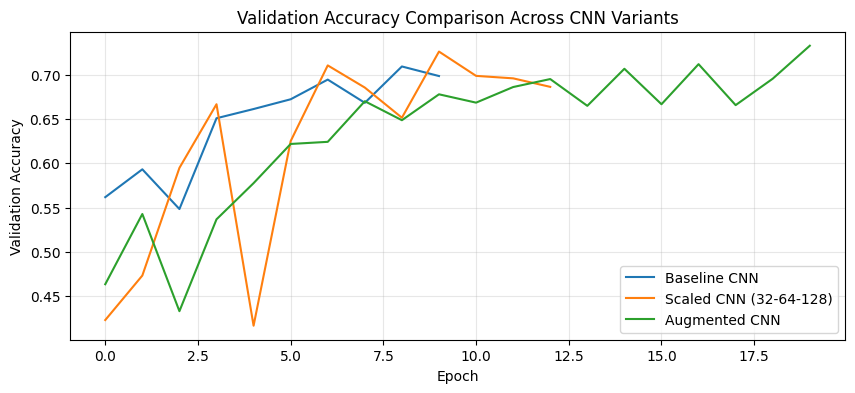

In [56]:
plt.figure(figsize=(10,4))
plt.plot(cnn_history.history['val_accuracy'], label='Baseline CNN')
plt.plot(cnn_scaled_history.history['val_accuracy'], label='Scaled CNN (32-64-128)')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison Across CNN Variants")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

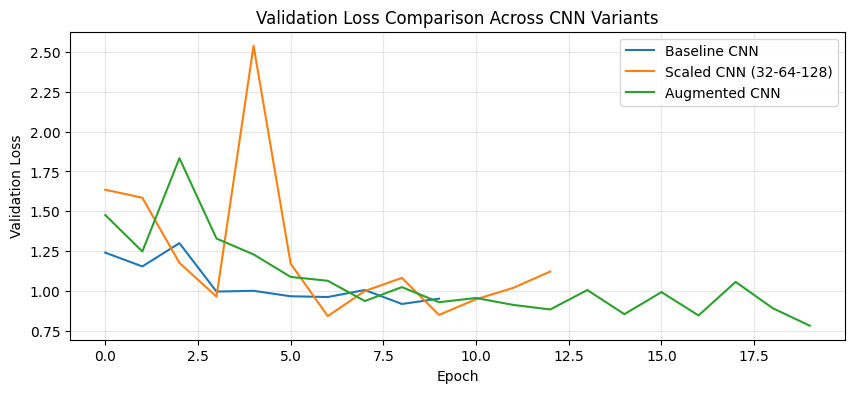

In [57]:
plt.figure(figsize=(10,4))
plt.plot(cnn_history.history['val_loss'], label='Baseline CNN')
plt.plot(cnn_scaled_history.history['val_loss'], label='Scaled CNN (32-64-128)')
plt.plot(aug_history.history['val_loss'], label='Augmented CNN')
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison Across CNN Variants")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

learning curves of bonus transfer learning

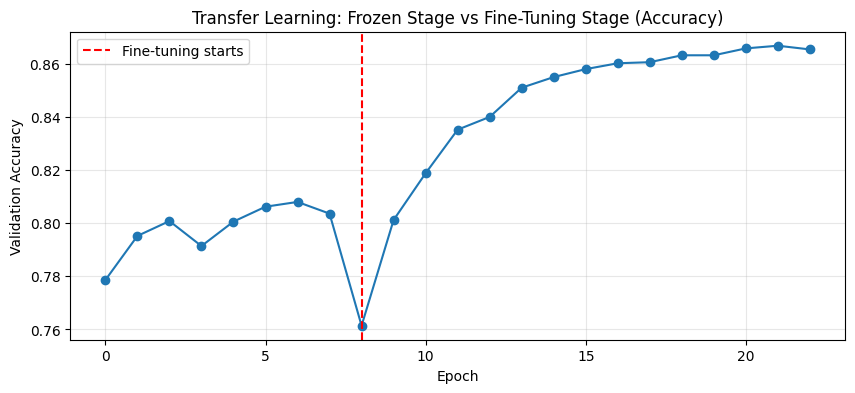

In [61]:
plt.figure(figsize=(10,4))
plt.plot(combined_val_acc, marker='o')
plt.axvline(x=len(stage1_history.history['val_accuracy']), color='red', linestyle='--', label='Fine-tuning starts')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Transfer Learning: Frozen Stage vs Fine-Tuning Stage (Accuracy)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

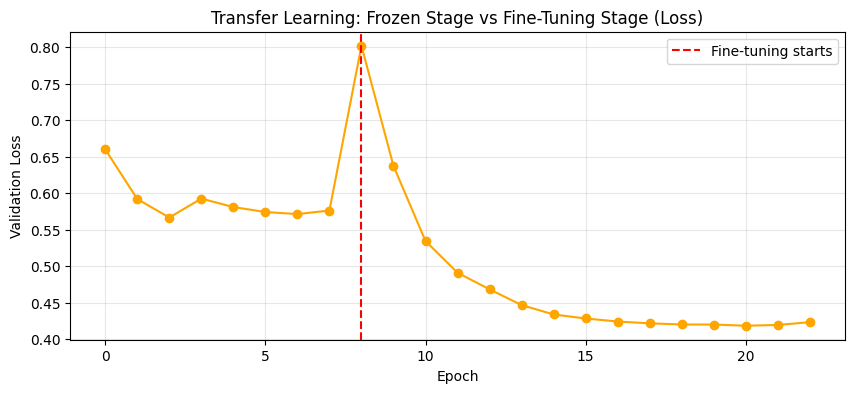

In [62]:
plt.figure(figsize=(10,4))
plt.plot(combined_val_loss, marker='o', color='orange')
plt.axvline(x=len(stage1_history.history['val_loss']), color='red', linestyle='--', label='Fine-tuning starts')
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Transfer Learning: Frozen Stage vs Fine-Tuning Stage (Loss)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

# 📊 Final Comparison Table

In [58]:
comparison = pd.DataFrame({
    "Model": ["ANN (baseline)", "CNN (baseline)", "ANN (deeper)", "CNN (scaled 32-64-128)", "CNN (augmented)"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, ann_deep_test_acc, cnn_scaled_test_acc, aug_test_acc],
    "Test Loss": [ann_test_loss, cnn_test_loss, ann_deep_test_loss, cnn_scaled_test_loss, aug_test_loss]
})

print(comparison)


best_model = comparison.loc[comparison["Test Accuracy"].idxmax()]
print("\nBest Model:", best_model["Model"])
print("Best Test Accuracy:", best_model["Test Accuracy"])
print("Best Test Loss:", best_model["Test Loss"])

                    Model  Test Accuracy  Test Loss
0          ANN (baseline)         0.4093   1.693687
1          CNN (baseline)         0.7011   0.959723
2            ANN (deeper)         0.3897   1.734119
3  CNN (scaled 32-64-128)         0.7127   0.845701
4         CNN (augmented)         0.7302   0.783929

Best Model: CNN (augmented)
Best Test Accuracy: 0.7301999926567078
Best Test Loss: 0.7839288711547852


bonus comparison table

In [63]:
bonus_comparison = pd.DataFrame({
    "Model": ["Best From-Scratch CNN (augmented)", "Transfer Learning (MobileNetV2, fine-tuned)"],
    "Test Accuracy": [aug_test_acc, transfer_test_acc],
    "Test Loss": [aug_test_loss, transfer_test_loss]
})

print(bonus_comparison)

                                         Model  Test Accuracy  Test Loss
0            Best From-Scratch CNN (augmented)         0.7302   0.783929
1  Transfer Learning (MobileNetV2, fine-tuned)         0.8612   0.411633


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**